# TakeMeter — Fine-Tuning Starter Notebook
### AI201 · Project 3

This notebook walks you through fine-tuning a text classifier on your annotated dataset and comparing it to a zero-shot baseline.

**What this notebook does for you (infrastructure):**
- Tokenizes your dataset and prepares it for training
- Runs the fine-tuning pipeline with DistilBERT
- Computes evaluation metrics and generates a confusion matrix
- Runs the Groq baseline and compares both models

**What you do (the actual work):**
- Collect and annotate your 200+ examples (done before opening this notebook)
- Define your label map and upload your CSV
- Write your Groq classification prompt using your label definitions
- Analyze the output and write your evaluation report

In [1]:
import torch
import transformers
import datasets
import sklearn
import pandas
import numpy
import matplotlib
import groq
import dotenv

print("✅ Dependencies ready (managed by uv)")

✅ Dependencies ready (managed by uv)


In [2]:
import pandas as pd
import numpy as np
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
import warnings
warnings.filterwarnings("ignore")

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA supported: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"MPS (Apple Silicon GPU) available: {torch.backends.mps.is_available()}")


✅ Imports complete
PyTorch version: 2.12.1
CUDA supported: False
MPS (Apple Silicon GPU) available: True


---
## Section 1: Load Your Dataset

Upload your labeled CSV and define your label map.  
Your CSV must have at least two columns: `text` (the post/comment) and `label` (your string label).

In [3]:
LABEL_MAP = {
    "technical_insight":  0,
    "opinion_or_critique": 1,
    "joke_or_meta":        2,
}

ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS = len(LABEL_MAP)
print(f"Labels: {LABEL_MAP}")
print(f"Number of labels: {NUM_LABELS}")


Labels: {'technical_insight': 0, 'opinion_or_critique': 1, 'joke_or_meta': 2}
Number of labels: 3


In [4]:
# Use a path relative to this notebook, or an absolute path.
# ─────────────────────────────────────────────────────────────────────────
CSV_PATH = "../data/hn_dataset_v3_full.csv"  # v2: +11 joke_or_meta from targeted scrape pass
import os
assert os.path.exists(CSV_PATH), f"File not found: {CSV_PATH} — update CSV_PATH above."
print(f"✅ Using dataset: {CSV_PATH}")

✅ Using dataset: ../data/hn_dataset_v3_full.csv


In [5]:
# Load and validate your dataset
df = pd.read_csv(CSV_PATH)

# ── TODO (if needed) ──────────────────────────────────────────────────────
# If your CSV uses different column names, rename them here.
# Example: df = df.rename(columns={"post": "text", "category": "label"})
# ── END TODO ──────────────────────────────────────────────────────────────

print(f"Columns: {df.columns.tolist()}")
print(f"Total examples: {len(df)}")
print()
print("Label distribution:")
print(df["label"].value_counts())

# Validate all labels are in LABEL_MAP
unknown = set(df["label"].unique()) - set(LABEL_MAP.keys())
if unknown:
    print(f"\n⚠️  Labels in CSV not found in LABEL_MAP: {unknown}")
    print("Update your LABEL_MAP above to include all labels.")
else:
    print("\n✅ All labels match your LABEL_MAP")

# Convert string labels to integers
df["label_id"] = df["label"].map(LABEL_MAP)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

Columns: ['story_title', 'story_url', 'text', 'label', 'notes']
Total examples: 224

Label distribution:
label
opinion_or_critique    121
joke_or_meta            52
technical_insight       51
Name: count, dtype: int64

✅ All labels match your LABEL_MAP


---
## Section 2: Prepare Data for Training

Splits your dataset into train / validation / test sets and tokenizes the text.

In [6]:
# Train / val / test split — 70% / 15% / 15%
# Stratified so each split has roughly the same label distribution.
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label_id"]
)

# Keep validation/test 100% REAL held-out data: move any synthetic boundary
# examples that landed in them back into TRAIN. Synthetic data should only ever
# be used for training, never for evaluation.
def _is_synth(d):
    return d["notes"].astype(str).str.contains("synthetic", na=False)

moved   = pd.concat([val_df[_is_synth(val_df)], test_df[_is_synth(test_df)]])
val_df  = val_df[~_is_synth(val_df)]
test_df = test_df[~_is_synth(test_df)]
train_df = pd.concat([train_df, moved])

# Reset indices (needed for clean HuggingFace Dataset conversion)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} examples "
      f"({len(moved)} synthetic moved out of val/test → all synthetic now train-only)")
print(f"Validation: {len(val_df)} examples (100% real)")
print(f"Test: {len(test_df)} examples (100% real)")
print()
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution (real held-out):")
print(test_df["label"].value_counts())

Train: 160 examples (4 synthetic moved out of val/test → all synthetic now train-only)
Validation: 34 examples (100% real)
Test: 30 examples (100% real)

Train label distribution:
label
opinion_or_critique    86
joke_or_meta           37
technical_insight      37
Name: count, dtype: int64

Test label distribution (real held-out):
label
opinion_or_critique    16
technical_insight       7
joke_or_meta            7
Name: count, dtype: int64


In [7]:
# Load tokenizer and tokenize all splits
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

def make_dataset(df_split):
    ds = Dataset.from_pandas(
        df_split[["text", "label_id"]].rename(columns={"label_id": "labels"})
    )
    return ds.map(tokenize, batched=True)

train_dataset = make_dataset(train_df)
val_dataset   = make_dataset(val_df)
test_dataset  = make_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Tokenization complete")
print(f"Sample keys: {list(train_dataset[0].keys())}")

Map:   0%|          | 0/160 [00:00<?, ? examples/s]

Map:   0%|          | 0/34 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

✅ Tokenization complete
Sample keys: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


---
## Section 3: Fine-Tune Your Model

Loads `distilbert-base-uncased` with a classification head and fine-tunes it on your training data.  
Training runs for 3 epochs and takes **5–15 minutes** on a T4 GPU.

> **Hyperparameter note:** The defaults below work well for datasets of 100–500 examples.  
> If you change any values, note what you changed and why in your README.

In [8]:
# Load DistilBERT with a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Output labels: {NUM_LABELS}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
Output labels: 3


In [9]:
from sklearn.metrics import f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1_macro": f1_score(labels, predictions, average="macro", zero_division=0), # updated to add f1 macro score
    }

In [10]:
# ── β-SWEEP: find the class-weight strength that maximizes VALIDATION macro-F1 ──
import numpy as np, torch
from torch import nn
from sklearn.metrics import f1_score

counts = np.array([(train_df["label_id"] == i).sum() for i in range(NUM_LABELS)], dtype=float)
print("Train counts [tech, opinion, joke]:", counts.astype(int))

def make_weights(beta):
    w = (counts.sum() / counts) ** beta     # inverse-freq tempered by β
    return torch.tensor(w / w.mean(), dtype=torch.float)   # mean≈1 → stable LR across β

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=self.class_weights.to(outputs.logits.device))(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def fresh_model():
    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_LABELS, id2label=ID_TO_LABEL, label2id=LABEL_MAP)

sweep = []
for beta in [0.0, 0.3, 0.5, 0.7, 1.0]:
    args = TrainingArguments(
        output_dir=f"./takemeter-sweep/beta_{beta}",
        num_train_epochs=6, per_device_train_batch_size=16, per_device_eval_batch_size=32,
        learning_rate=2e-5, weight_decay=0.01, warmup_ratio=0.1,
        eval_strategy="no", save_strategy="no", logging_steps=50,
        report_to="none", disable_tqdm=True, seed=42)        # fixed seed → β is the only variable
    t = WeightedTrainer(model=fresh_model(), args=args,
        train_dataset=train_dataset, eval_dataset=val_dataset,
        data_collator=data_collator, compute_metrics=compute_metrics,
        class_weights=make_weights(beta))
    t.train()
    out = t.predict(val_dataset)
    pred, true = np.argmax(out.predictions, axis=-1), out.label_ids
    macro, acc = f1_score(true, pred, average="macro"), (pred == true).mean()
    sweep.append((beta, macro, acc))
    print(f"β={beta:.1f}  val_macroF1={macro:.3f}  val_acc={acc:.3f}")

best_beta = max(sweep, key=lambda x: x[1])[0]
print(f"\n👉 Best β on validation macro-F1: {best_beta}")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Train counts [tech, opinion, joke]: [37 86 37]


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '0.8943', 'grad_norm': '3.114', 'learning_rate': '4.074e-06', 'epoch': '5'}
{'train_runtime': '33.58', 'train_samples_per_second': '28.59', 'train_steps_per_second': '1.787', 'train_loss': '0.859', 'epoch': '6'}


...

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


β=0.7  val_macroF1=0.656  val_acc=0.735


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '0.9513', 'grad_norm': '2.957', 'learning_rate': '4.074e-06', 'epoch': '5'}
{'train_runtime': '32.18', 'train_samples_per_second': '29.83', 'train_steps_per_second': '1.864', 'train_loss': '0.9158', 'epoch': '6'}
β=1.0  val_macroF1=0.787  val_acc=0.794

👉 Best β on validation macro-F1: 1.0


In [11]:
# Hyperparameter tweaks
# Change #1 - Removed warmup_steps = 50, changed to warmup_ratio=0.1
    # warmup_steps = 50 is nonsensical because with 150 train examples & a batch size of 16, total steps = 30
    # since 30 < 50, every single step will be in the warm-up phase.
    # And in general, instead of hard-coding the warmup_steps, setting a warmup ratio (i.e setting warmup to 10% of the total step count) is a better design choice

# Change #2 - num_train_epochs= 3 → 6
    # It is true that 3 is a good default for fine-tuning BERT models, however, Zhang et. al 2021 found in their paper Revisiting Few-sample BERT Fine-tuning
    # that for smaller size datasets, more epoches actually lead to better performance, contrary to what the original claim said ("3 is a good default for small datasets")
    # In fact, the 3 epoch rule is suggested based on BERT's original benchmarks ran on a 3~9k sample size. We have a ~200 sample size.

# Change #3 - metric_for_best_model="accuracy" → "f1_macro"
    # Looking at our label distribution for the training dataset, we see that our set is ~(50% opinion, 25% joke, 25% technical).
    # Given the dominance of the opinion class, accuracy is really not an optimal benchmark because a model that is really good at predicting opinions and sub-optimal at the two minorities can win on accuracy
    # Macro-f1 grades each class seaparately and averages the three scores, so a checkpoint wins only if it is good at all three labels.
    # A tradeoff is that macro-F1 will be noisier than accuracy, but in general noise is better than a systematic bias.

# Change #4 - class weights set by the β-sweep via make_weights(best_beta), not hardcoded.
    # The old hardcoded weights [1.67, 0.59, 1.43] were computed for the PREVIOUS dataset's counts
    # (technical=30, opinion=85, joke=35). make_weights() recomputes from the current train split,
    # and best_beta is the strength that maximized validation macro-F1 in the sweep cell above.

# Prev (original) hyperparameters, for reference:
#   num_train_epochs=3, warmup_steps=50, metric_for_best_model="accuracy"

training_args = TrainingArguments(
    output_dir="./takemeter-model",
    num_train_epochs=6,                  # Change #2
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,                    # Change #1
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",    # Change #3
    logging_steps=10,
    report_to="none",
    seed=42,
)

# Reuses WeightedTrainer / make_weights / fresh_model from the β-sweep cell above.
trainer = WeightedTrainer(
    model=fresh_model(),                       # fresh weights, not a re-trained model
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    class_weights=make_weights(best_beta),     # ← Change #4: the sweep winner
    compute_metrics=compute_metrics,
)

print(f"Starting final fine-tuning at β={best_beta} ...")
trainer.train()
print("\n✅ Fine-tuning complete")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting final fine-tuning at β=1.0 ...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.101342,1.077527,0.294118,0.213083
2,1.050300,1.026128,0.470588,0.494017
3,0.966881,0.941781,0.617647,0.621053
4,0.860172,0.862487,0.764706,0.761220
5,0.778051,0.814759,0.794118,0.786937
6,0.737895,0.800622,0.794118,0.786937


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuning complete


---
## Section 4: Evaluate Fine-Tuned Model on Test Set

Runs inference on your locked test set and generates metrics and a confusion matrix.  
These numbers go directly into your evaluation report.

In [12]:
# Run inference on the test set
print("Running inference on test set...")
ft_output = trainer.predict(test_dataset)
ft_pred_ids = np.argmax(ft_output.predictions, axis=-1)
ft_true_ids = ft_output.label_ids

ft_probs = torch.nn.functional.softmax(
    torch.tensor(ft_output.predictions), dim=-1
).numpy()

# Overall accuracy
ft_accuracy = accuracy_score(ft_true_ids, ft_pred_ids)
print(f"\n🎯 Fine-tuned model accuracy: {ft_accuracy:.3f}")

# Per-class metrics
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("\nPer-class metrics (fine-tuned model):")
print(classification_report(ft_true_ids, ft_pred_ids, target_names=label_names, zero_division=0))

Running inference on test set...



🎯 Fine-tuned model accuracy: 0.633

Per-class metrics (fine-tuned model):
                     precision    recall  f1-score   support

  technical_insight       0.71      0.71      0.71         7
opinion_or_critique       0.73      0.50      0.59        16
       joke_or_meta       0.50      0.86      0.63         7

           accuracy                           0.63        30
          macro avg       0.65      0.69      0.65        30
       weighted avg       0.67      0.63      0.63        30



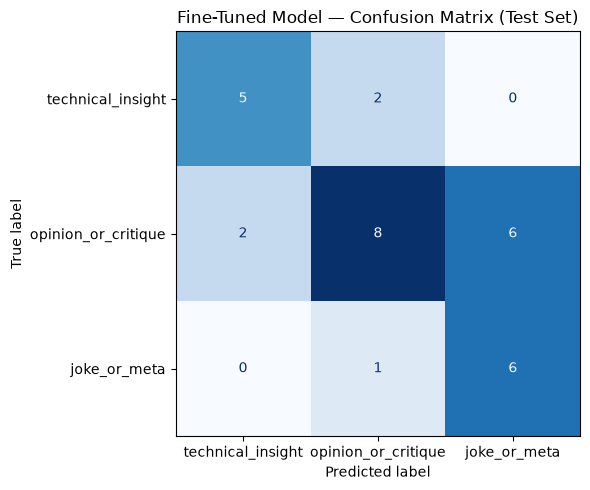

✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README


In [13]:
# Confusion matrix
cm = confusion_matrix(ft_true_ids, ft_pred_ids)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Fine-Tuned Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README")

In [14]:
# Print wrong predictions for your error analysis
# Review these carefully — pick 3 to analyze in depth in your README.

wrong_idx = np.where(ft_pred_ids != ft_true_ids)[0]
print(f"Wrong predictions: {len(wrong_idx)} / {len(ft_true_ids)}\n")

for i, idx in enumerate(wrong_idx[:15]):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    print(f"--- #{i+1} ---")
    print(f"Text:      {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"True:      {true_label}")
    print(f"Predicted: {pred_label}  (confidence: {confidence:.2f})")
    print()

Wrong predictions: 11 / 30

--- #1 ---
Text:      Well I was thinking about making a competitor to SPI because they only support GitHub repo’s.This news makes it easy. I’m starting the engines on this…
True:      opinion_or_critique
Predicted: joke_or_meta  (confidence: 0.45)

--- #2 ---
Text:      Voice dictation is so much better than GBoard, which I've been using until now. It capitalizes and punctuates sentences without me needing to, and got several sentences perfect without any post-editin...
True:      opinion_or_critique
Predicted: technical_insight  (confidence: 0.49)

--- #3 ---
Text:      Great timing given I just installed SwiftKey since Microsoft has started embedding ads and dark pattern redirects to Bing!
True:      opinion_or_critique
Predicted: joke_or_meta  (confidence: 0.49)

--- #4 ---
Text:      Data shows that introduction of iPhones in 2007 is a better explanation for the increase in pedestrian deaths than heavier trucks and SUVs: https://www.reddit.com/r/dataisb

---
## Section 5: Baseline Classifier (Groq)

Runs your zero-shot baseline using `llama-3.3-70b-versatile`.  
You need to write the classification prompt using your label definitions.

In [15]:
from groq import Groq
import os
from dotenv import load_dotenv

# Loads GROQ_API_KEY from the .env file in the same directory as this notebook.
load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

assert GROQ_API_KEY, (
    "GROQ_API_KEY not found — make sure your .env file exists and contains: "
    "GROQ_API_KEY=your_key_here"
)

client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client initialized")


✅ Groq client initialized


In [16]:
SYSTEM_PROMPT = """
You are classifying Hacker News comments into exactly one of three categories.

technical_insight: The commenter explains how something works under the hood, shares a specific engineering experience, or corrects a technical misconception with concrete details. The comment must contain an actual explanation or substantive new information — dropping a technical term alone is not sufficient.
Example: "Actually, the reason this database is slow is because of how Postgres handles MVCC. When you have high update churn, the vacuum process can't keep up, leading to table bloat and sequential scans."

opinion_or_critique: The commenter shares a strong personal opinion, complains about a company or technology, or debates the merits of the post without providing a deep technical explanation or evidence.
Example: "This entire startup is just a thin wrapper around OpenAI's API. There is absolutely no moat here."

joke_or_meta: The comment is pure sarcasm, a meme, or a meta-comment about Hacker News itself.
Example: "Can't wait to rewrite this in Rust next week."

Respond with ONLY the label name, exactly as written below. Do not explain your reasoning.

Valid labels:
technical_insight
opinion_or_critique
joke_or_meta
"""

print("Prompt length:", len(SYSTEM_PROMPT), "characters")


Prompt length: 1225 characters


In [17]:
def classify_with_groq(text):
    """Classify a single post. Returns a label string or None if unparseable."""
    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Classify this post:\n\n{text}"},
            ],
            temperature=0,
            max_tokens=20,
        )
        raw = response.choices[0].message.content.strip().lower()
        # Match the model's output to a label. Check longest labels first so a
        # label that is a substring of another (e.g. "recommendation" vs.
        # "strong_recommendation") can't be matched by mistake.
        for label in sorted(LABEL_MAP, key=len, reverse=True):
            if raw == label or label in raw:
                return label
        return None  # model output didn't match any known label
    except Exception as e:
        print(f"API error: {e}")
        return None


# Run baseline on test set
print(f"Running baseline on {len(test_df)} examples...")
print("(May take a few minutes — 0.1s delay between requests to respect free-tier limits)\n")

baseline_preds = []
for i, (_, row) in enumerate(test_df.iterrows()):
    pred = classify_with_groq(row["text"])
    baseline_preds.append(pred)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(test_df)} complete...")
    time.sleep(0.1)

none_count = baseline_preds.count(None)
if none_count > 0:
    print(f"\n⚠️  {none_count} responses could not be parsed.")
    print("Review your prompt — the model may not be outputting clean label names.")

Running baseline on 30 examples...
(May take a few minutes — 0.1s delay between requests to respect free-tier limits)

  10/30 complete...
  20/30 complete...
  30/30 complete...


In [18]:
# Baseline metrics (exclude unparseable responses)
valid = [(p, t) for p, t in zip(baseline_preds, test_df["label_id"])
         if p is not None]
bl_pred_ids = [LABEL_MAP[p] for p, _ in valid]
bl_true_ids = [t for _, t in valid]

bl_accuracy = accuracy_score(bl_true_ids, bl_pred_ids)
print(f"Baseline accuracy: {bl_accuracy:.3f}  "
      f"(evaluated on {len(valid)}/{len(test_df)} parseable responses)")
print()
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("Per-class metrics (baseline):")
print(classification_report(bl_true_ids, bl_pred_ids, target_names=label_names, zero_division=0))

Baseline accuracy: 0.633  (evaluated on 30/30 parseable responses)

Per-class metrics (baseline):
                     precision    recall  f1-score   support

  technical_insight       0.50      0.86      0.63         7
opinion_or_critique       0.67      0.62      0.65        16
       joke_or_meta       1.00      0.43      0.60         7

           accuracy                           0.63        30
          macro avg       0.72      0.64      0.63        30
       weighted avg       0.71      0.63      0.63        30



---
## Section 6: Compare Results and Export

Side-by-side comparison of both models.  
Download the output files and commit them to your GitHub repo.

In [19]:
print("=" * 50)
print("RESULTS COMPARISON")
print("=" * 50)
print(f"{'Model':<35} {'Accuracy':>8}")
print("-" * 45)
print(f"{'Zero-shot baseline (Groq)':<35} {bl_accuracy:>8.3f}")
print(f"{'Fine-tuned DistilBERT':<35} {ft_accuracy:>8.3f}")
print("-" * 45)
delta = ft_accuracy - bl_accuracy
direction = "improvement" if delta >= 0 else "regression"
print(f"\nFine-tuning {direction}: {abs(delta):.3f}")
print()
print("Use these numbers in your README evaluation report.")

RESULTS COMPARISON
Model                               Accuracy
---------------------------------------------
Zero-shot baseline (Groq)              0.633
Fine-tuned DistilBERT                  0.633
---------------------------------------------

Fine-tuning improvement: 0.000

Use these numbers in your README evaluation report.


In [20]:
# Save results JSON — commit to your GitHub repo and reference in README
results = {
    "baseline_accuracy": round(bl_accuracy, 4),
    "finetuned_accuracy": round(ft_accuracy, 4),
    "improvement": round(ft_accuracy - bl_accuracy, 4),
    "test_set_size": len(test_df),
    "label_map": LABEL_MAP,
    "model": MODEL_NAME,
}
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Files ready to download:")
print("   evaluation_results.json  — metrics for your README")
print("   confusion_matrix.png     — include in your README")
print()
print("Download via: Files panel (📁) on the left → right-click → Download")

✅ Files ready to download:
   evaluation_results.json  — metrics for your README
   confusion_matrix.png     — include in your README

Download via: Files panel (📁) on the left → right-click → Download


In [21]:
# ── Section 7: Numbers for the README ──
# Run this AFTER Sections 4 (fine-tuned) and 5 (baseline) so bl_* and ft_* exist.
from sklearn.metrics import classification_report, confusion_matrix, f1_score
names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]

# ── 1 & 2: BASELINE per-class + macro-F1 (the two README placeholders) ──
print("=== BASELINE (LLaMA-70B) per-class ===")
print(classification_report(bl_true_ids, bl_pred_ids, target_names=names, zero_division=0))
print("Baseline macro-F1:", round(f1_score(bl_true_ids, bl_pred_ids, average="macro"), 3))
print("Fine-tuned macro-F1:", round(f1_score(ft_true_ids, ft_pred_ids, average="macro"), 3))

# ── 3: SAMPLE CLASSIFICATIONS — correct ones with confidence ──
print("\n=== CORRECT predictions (pick 1-2 for the README; jokes are usually all correct) ===")
for idx in range(len(test_df)):
    if ft_true_ids[idx] == ft_pred_ids[idx]:
        c = ft_probs[idx][ft_pred_ids[idx]]
        print(f"{ID_TO_LABEL[ft_pred_ids[idx]]:<20} conf={c:.2f} | {test_df.iloc[idx]['text'][:75]}")

=== BASELINE (LLaMA-70B) per-class ===
                     precision    recall  f1-score   support

  technical_insight       0.50      0.86      0.63         7
opinion_or_critique       0.67      0.62      0.65        16
       joke_or_meta       1.00      0.43      0.60         7

           accuracy                           0.63        30
          macro avg       0.72      0.64      0.63        30
       weighted avg       0.71      0.63      0.63        30

Baseline macro-F1: 0.626
Fine-tuned macro-F1: 0.646

=== CORRECT predictions (pick 1-2 for the README; jokes are usually all correct) ===
technical_insight    conf=0.51 | The survey in the article that assessed vitamin D deficiency was a bit odd:
opinion_or_critique  conf=0.44 | In democracy, there is a distinction between peacetime power and wartime po
opinion_or_critique  conf=0.44 | I'm wondering whether this is a permanent change. After all the easy-to-fin
joke_or_meta         conf=0.41 | Only thing left is to make a Kanb